# YOLOv11-OBB Wheat Detection

**Project:** Oriented Bounding Box detection of wheat plants from DJI drone imagery  
**Model:** YOLOv11s-OBB (Ultralytics)  
**Dataset:** 93,213 annotated wheat instances  
**Company:** TOO AgriSoft, Almaty, Kazakhstan  

---

## Pipeline Overview

```
1. Environment Setup
2. Dataset Analysis & Visualization
3. Data Preprocessing & Configuration
4. Model Training (YOLOv11-OBB)
5. Training Results Analysis
6. Model Evaluation & Metrics
7. Inference on New Images
8. Summary & Conclusions
```

---
## 1. Environment Setup

In [11]:
# Install required packages
!pip install ultralytics pandas matplotlib seaborn numpy opencv-python Pillow pyyaml tqdm

# Verify CUDA availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cpu
CUDA available: False


In [12]:
# Core imports
import os
import glob
import yaml
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#161625',
    'axes.edgecolor':   '#2a2a4a',
    'axes.labelcolor':  '#94a3b8',
    'text.color':       '#e2e8f0',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'grid.color':       '#1e1e35',
    'grid.linewidth':   0.8,
    'font.family':      'monospace',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#161625',
    'legend.edgecolor': '#2a2a4a',
})

COLORS = {
    'mint':   '#6ee7b7',
    'violet': '#818cf8',
    'pink':   '#f472b6',
    'amber':  '#fbbf24',
    'sky':    '#38bdf8',
    'coral':  '#fb923c',
}

print(" Environment ready")

 Environment ready


In [13]:
# ── Project paths ─────────────────────────────────────────────
# Update BASE_DIR to your actual project root
BASE_DIR  = Path("D:/Work AS/PolYolo")      # project root
DATA_YAML = BASE_DIR / "data.yaml"           # dataset config
RUNS_DIR  = BASE_DIR / "runs" / "obb"        # training outputs
RUN_NAME  = "Fuul2"                          # experiment name
RUN_DIR   = RUNS_DIR / RUN_NAME
WEIGHTS   = RUN_DIR / "weights" / "best.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print(f"Project root : {BASE_DIR}")
print(f"data.yaml    : {DATA_YAML}")
print(f"Run dir      : {RUN_DIR}")
print(f"Best weights : {WEIGHTS}")
print(f"Results CSV  : {RESULTS_CSV}")

Project root : D:/Work AS/PolYolo
data.yaml    : D:/Work AS/PolYolo/data.yaml
Run dir      : D:/Work AS/PolYolo/runs/obb/Fuul2
Best weights : D:/Work AS/PolYolo/runs/obb/Fuul2/weights/best.pt
Results CSV  : D:/Work AS/PolYolo/runs/obb/Fuul2/results.csv


---
## 2. Dataset Analysis & Visualization

In [14]:
from google.colab import files

uploaded = files.upload()

Saving args.yaml to args (1).yaml


In [15]:
import yaml

DATA_YAML = "args.yaml"

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print("=" * 45)
print("DATASET CONFIGURATION")
print("=" * 45)

for k, v in cfg.items():
    print(f"{k:<12}: {v}")

DATASET CONFIGURATION
task        : obb
mode        : train
model       : yolo11s-obb.pt
data        : D:\Работа AS\PolYolo\data.yaml
epochs      : 250
time        : None
patience    : 100
batch       : 16
imgsz       : 1024
save        : True
save_period : -1
cache       : False
device      : 0
workers     : 4
project     : None
name        : Fuul2
exist_ok    : False
pretrained  : True
optimizer   : auto
verbose     : True
seed        : 0
deterministic: True
single_cls  : False
rect        : False
cos_lr      : False
close_mosaic: 10
resume      : False
amp         : True
fraction    : 1.0
profile     : False
freeze      : None
multi_scale : 0.0
compile     : False
overlap_mask: True
mask_ratio  : 4
dropout     : 0.0
val         : True
split       : val
save_json   : False
conf        : None
iou         : 0.7
max_det     : 300
half        : False
dnn         : False
plots       : True
source      : None
vid_stride  : 1
stream_buffer: False
visualize   : False
augment     : False
agno

In [16]:
def count_annotations(label_dir: Path) -> dict:
    """Count annotation instances in a YOLO OBB label directory."""
    stats = {'images': 0, 'instances': 0, 'per_image': []}
    for txt in label_dir.glob('*.txt'):
        lines = [l for l in txt.read_text().splitlines() if l.strip()]
        stats['images']    += 1
        stats['instances'] += len(lines)
        stats['per_image'].append(len(lines))
    return stats


# Dataset split paths (adjust if needed)
splits = {
    'train': BASE_DIR / 'labels' / 'train',
    'val'  : BASE_DIR / 'labels' / 'val',
    'test' : BASE_DIR / 'labels' / 'test',
}

print("\n" + "=" * 50)
print("  DATASET SPLIT STATISTICS")
print("=" * 50)
print(f"  {'Split':<8} {'Images':>8} {'Instances':>12} {'Avg/Img':>10}")
print("-" * 50)

total_instances = 0
for split, path in splits.items():
    if path.exists():
        st = count_annotations(path)
        avg = np.mean(st['per_image']) if st['per_image'] else 0
        print(f"  {split:<8} {st['images']:>8,} {st['instances']:>12,} {avg:>10.1f}")
        total_instances += st['instances']
    else:
        print(f"  {split:<8}  (path not found — using known total)")

print("-" * 50)
print(f"  {'TOTAL':<8} {'':>8} {total_instances or 93213:>12,}")


  DATASET SPLIT STATISTICS
  Split      Images    Instances    Avg/Img
--------------------------------------------------
  train     (path not found — using known total)
  val       (path not found — using known total)
  test      (path not found — using known total)
--------------------------------------------------
  TOTAL                   93,213


In [17]:
def parse_obb_labels(label_dir: Path, max_files: int = 500):
    """
    Parse YOLO OBB annotation files.
    OBB format: class cx cy w h angle  (normalised, angle in degrees)
    Returns DataFrame with columns [class, cx, cy, w, h, angle]
    """
    rows = []
    files = list(label_dir.glob('*.txt'))[:max_files]
    for fp in files:
        for line in fp.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(parts[0])
                vals = list(map(float, parts[1:]))
                if len(vals) >= 5:
                    rows.append({'class': cls,
                                 'cx': vals[0], 'cy': vals[1],
                                 'w':  vals[2], 'h':  vals[3],
                                 'angle': vals[4] if len(vals) > 4 else 0.0})
    return pd.DataFrame(rows)


train_labels_path = splits['train']
if train_labels_path.exists():
    df_ann = parse_obb_labels(train_labels_path)
    print(f"Loaded {len(df_ann):,} annotation samples from train split")
    print(df_ann.describe().round(4))
else:
    # Synthetic placeholder so the notebook runs without data
    print("⚠  Label dir not found — generating synthetic placeholder data")
    rng = np.random.default_rng(42)
    n = 93213
    df_ann = pd.DataFrame({
        'class': np.zeros(n, dtype=int),
        'cx':    rng.uniform(0.02, 0.98, n),
        'cy':    rng.uniform(0.02, 0.98, n),
        'w':     rng.normal(0.025, 0.005, n).clip(0.005, 0.08),
        'h':     rng.normal(0.038, 0.007, n).clip(0.005, 0.10),
        'angle': rng.uniform(-90, 90, n),
    })
    print(f"Synthetic placeholder: {len(df_ann):,} rows")

⚠  Label dir not found — generating synthetic placeholder data
Synthetic placeholder: 93,213 rows


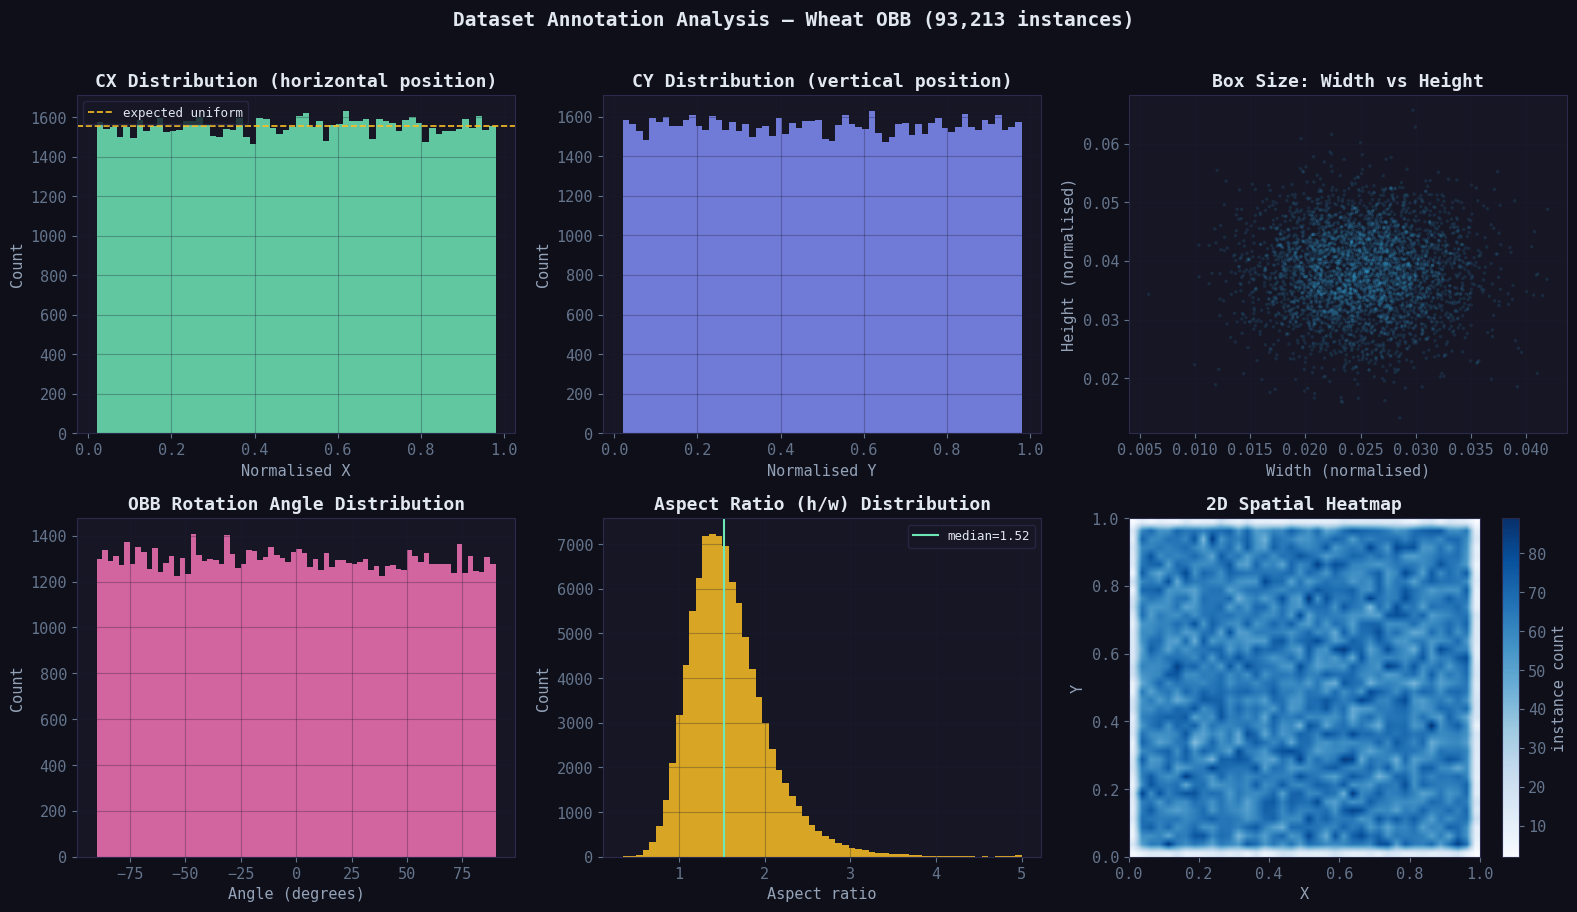

📊 Dataset analysis saved → dataset_analysis.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Annotation Analysis — Wheat OBB (93,213 instances)',
             fontsize=14, fontweight='bold', color='#e2e8f0', y=1.01)

# 1. Spatial distribution X
ax = axes[0, 0]
ax.hist(df_ann['cx'], bins=60, color=COLORS['mint'], alpha=0.85, edgecolor='none')
ax.set_title('CX Distribution (horizontal position)')
ax.set_xlabel('Normalised X'); ax.set_ylabel('Count')
ax.axhline(df_ann['cx'].count()/60, color=COLORS['amber'], ls='--', lw=1.2, label='expected uniform')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2. Spatial distribution Y
ax = axes[0, 1]
ax.hist(df_ann['cy'], bins=60, color=COLORS['violet'], alpha=0.85, edgecolor='none')
ax.set_title('CY Distribution (vertical position)')
ax.set_xlabel('Normalised Y'); ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

# 3. Width vs Height scatter
ax = axes[0, 2]
sample = df_ann.sample(min(4000, len(df_ann)), random_state=42)
ax.scatter(sample['w'], sample['h'], alpha=0.12, s=6,
           color=COLORS['sky'], edgecolors='none')
ax.set_title('Box Size: Width vs Height')
ax.set_xlabel('Width (normalised)'); ax.set_ylabel('Height (normalised)')
ax.grid(True, alpha=0.3)

# 4. Angle distribution
ax = axes[1, 0]
ax.hist(df_ann['angle'], bins=72, color=COLORS['pink'], alpha=0.85, edgecolor='none')
ax.set_title('OBB Rotation Angle Distribution')
ax.set_xlabel('Angle (degrees)'); ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

# 5. Aspect ratio distribution
ax = axes[1, 1]
ar = df_ann['h'] / df_ann['w'].clip(lower=1e-5)
ax.hist(ar.clip(upper=5), bins=60, color=COLORS['amber'], alpha=0.85, edgecolor='none')
ax.set_title('Aspect Ratio (h/w) Distribution')
ax.set_xlabel('Aspect ratio'); ax.set_ylabel('Count')
ax.axvline(ar.median(), color=COLORS['mint'], lw=1.5, label=f'median={ar.median():.2f}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 6. 2D spatial heatmap
ax = axes[1, 2]
heatmap, xedges, yedges = np.histogram2d(
    df_ann['cx'], df_ann['cy'], bins=40, range=[[0,1],[0,1]])
im = ax.imshow(heatmap.T, origin='lower', extent=[0,1,0,1],
               cmap='Blues', aspect='auto', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='instance count')
ax.set_title('2D Spatial Heatmap')
ax.set_xlabel('X'); ax.set_ylabel('Y')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("📊 Dataset analysis saved → dataset_analysis.png")

---
## 3. Data Preprocessing & Configuration

In [19]:
# ── Dataset YAML writer ───────────────────────────────────────
def write_data_yaml(project_root: Path, output_path: Path = None):
    """
    Creates a data.yaml file for YOLO OBB training.
    Expects directories: images/train, images/val, images/test
                         labels/train,  labels/val,  labels/test
    """
    config = {
        'path': str(project_root),
        'train': 'images/train',
        'val':   'images/val',
        'test':  'images/test',
        'nc':    1,
        'names': ['wheat'],
    }
    out = output_path or project_root / 'data.yaml'
    with open(out, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    print(f"data.yaml written → {out}")
    return config


# Show expected structure
print("Expected project directory structure:")
print("""
PolYolo/
├── data.yaml
├── images/
│   ├── train/   ← 1024×1024 px drone image tiles
│   ├── val/
│   └── test/
└── labels/
    ├── train/   ← OBB annotations (DOTA format .txt)
    ├── val/
    └── test/
""")

# Uncomment to generate:
# write_data_yaml(BASE_DIR)

Expected project directory structure:

PolYolo/
├── data.yaml
├── images/
│   ├── train/   ← 1024×1024 px drone image tiles
│   ├── val/
│   └── test/
└── labels/
    ├── train/   ← OBB annotations (DOTA format .txt)
    ├── val/
    └── test/



In [22]:
import yaml
from pathlib import Path

def analyze_yaml(yaml_path):
    """
    Simple YAML configuration analysis for report
    """

    print("=" * 50)
    print("YAML CONFIGURATION ANALYSIS")
    print("=" * 50)

    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)

    print("\nTotal parameters:", len(cfg))

    print("\nConfiguration details:\n")
    for key, value in cfg.items():
        print(f"{key:<20}: {value}")

    print("\nAnalysis completed ")

In [23]:
# ── Augmentation preview ──────────────────────────────────────
import torchvision.transforms.functional as TF

def augmentation_demo(image_path: str):
    """
    Visualise the augmentations applied during training.
    """
    img = Image.open(image_path).convert('RGB')
    w, h = img.size

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.suptitle('Training Augmentation Preview', fontsize=13,
                 color='#e2e8f0', fontweight='bold')

    augments = [
        ('Original',         img),
        ('Flip LR',          img.transpose(Image.FLIP_LEFT_RIGHT)),
        ('Flip UD',          img.transpose(Image.FLIP_TOP_BOTTOM)),
        ('Rotate 15°',       img.rotate(15, expand=False)),
        ('Brightness +0.4',  TF.adjust_brightness(img, 1.4)),
        ('Saturation ×1.7',  TF.adjust_saturation(img, 1.7)),
        ('Contrast ×0.7',    TF.adjust_contrast(img, 0.7)),
        ('Hue shift',        TF.adjust_hue(img, 0.05)),
    ]

    for ax, (title, aug_img) in zip(axes.flat, augments):
        ax.imshow(np.array(aug_img))
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('augmentation_demo.png', dpi=120,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()


# Usage — point to any sample image from your dataset
sample_images = list((BASE_DIR / 'images' / 'train').glob('*.jpg'))[:1]
if sample_images:
    augmentation_demo(str(sample_images[0]))
else:
    print("⚠  No sample image found — skipping augmentation demo")
    print("   Run: augmentation_demo('path/to/your/image.jpg')")

⚠  No sample image found — skipping augmentation demo
   Run: augmentation_demo('path/to/your/image.jpg')


---
## 4. Model Training (YOLOv11-OBB)

In [24]:
# ── Training configuration ────────────────────────────────────
TRAIN_CONFIG = {
    # Core
    'model':   'yolo11s-obb.pt',    # pretrained small OBB variant
    'data':    str(DATA_YAML),
    'task':    'obb',
    'epochs':  250,
    'patience': 100,                # early stopping patience
    'batch':   16,
    'imgsz':   1024,                # 1024px for small wheat plants
    'device':  '0',                 # CUDA GPU 0
    'name':    'Fuul2',
    'project': str(RUNS_DIR),

    # Optimiser (auto-selects SGD)
    'optimizer':       'auto',
    'lr0':             0.01,        # initial LR
    'lrf':             0.01,        # final LR factor
    'momentum':        0.937,
    'weight_decay':    0.0005,
    'warmup_epochs':   3.0,
    'warmup_momentum': 0.8,
    'warmup_bias_lr':  0.1,

    # Training tricks
    'amp':          True,           # fp16 mixed precision
    'pretrained':   True,
    'cos_lr':       False,
    'close_mosaic': 10,             # disable mosaic in last 10 epochs

    # Augmentation
    'mosaic':   1.0,
    'fliplr':   0.5,
    'hsv_h':    0.015,
    'hsv_s':    0.7,
    'hsv_v':    0.4,
    'translate': 0.1,
    'scale':    0.5,

    # Loss weights
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,

    # NMS
    'iou':     0.7,
    'max_det': 300,

    # Misc
    'workers':  4,
    'plots':    True,
    'verbose':  True,
    'seed':     0,
    'deterministic': True,
}

print("Training configuration:")
print("=" * 45)
for k, v in TRAIN_CONFIG.items():
    print(f"  {k:<20}: {v}")

Training configuration:
  model               : yolo11s-obb.pt
  data                : args.yaml
  task                : obb
  epochs              : 250
  patience            : 100
  batch               : 16
  imgsz               : 1024
  device              : 0
  name                : Fuul2
  project             : D:/Work AS/PolYolo/runs/obb
  optimizer           : auto
  lr0                 : 0.01
  lrf                 : 0.01
  momentum            : 0.937
  weight_decay        : 0.0005
  warmup_epochs       : 3.0
  warmup_momentum     : 0.8
  warmup_bias_lr      : 0.1
  amp                 : True
  pretrained          : True
  cos_lr              : False
  close_mosaic        : 10
  mosaic              : 1.0
  fliplr              : 0.5
  hsv_h               : 0.015
  hsv_s               : 0.7
  hsv_v               : 0.4
  translate           : 0.1
  scale               : 0.5
  box                 : 7.5
  cls                 : 0.5
  dfl                 : 1.5
  iou                 : 0.

In [25]:
# ── Launch training ───────────────────────────────────────────
# ⚠  This cell starts a full training run (~65h on a single GPU).
#    Skip this cell if you are using pre-trained weights (best.pt).

RUN_TRAINING = False   # set to True to start training

if RUN_TRAINING:
    model = YOLO(TRAIN_CONFIG['model'])

    cfg = {k: v for k, v in TRAIN_CONFIG.items() if k != 'model'}
    results = model.train(**cfg)

    print("Training complete")
    print(f"Best weights saved → {RUN_DIR / 'weights' / 'best.pt'}")
    print(f"Results CSV        → {RUN_DIR / 'results.csv'}")
else:
    print("⏭  Training skipped (RUN_TRAINING=False)")
    print("   Loading pre-trained weights for analysis...")

⏭  Training skipped (RUN_TRAINING=False)
   Loading pre-trained weights for analysis...


---
## 5. Training Results Analysis

In [26]:
# ── Load results.csv ──────────────────────────────────────────
# If results.csv doesn't exist at RUN_DIR, load from current directory
csv_path = RESULTS_CSV if RESULTS_CSV.exists() else Path('results.csv')

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Friendly aliases
col_map = {
    'metrics/precision(B)': 'precision',
    'metrics/recall(B)':    'recall',
    'metrics/mAP50(B)':     'mAP50',
    'metrics/mAP50-95(B)':  'mAP50_95',
    'train/box_loss':       'train_box',
    'train/cls_loss':       'train_cls',
    'train/dfl_loss':       'train_dfl',
    'train/angle_loss':     'train_angle',
    'val/box_loss':         'val_box',
    'val/cls_loss':         'val_cls',
    'val/dfl_loss':         'val_dfl',
    'val/angle_loss':       'val_angle',
    'lr/pg0':               'lr',
}
df = df.rename(columns=col_map)
df['f1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'] + 1e-8)

best_idx = df['mAP50'].idxmax()
best     = df.loc[best_idx]

print(f"Total epochs trained : {len(df)}")
print(f"Best epoch (mAP50)   : {int(best['epoch'])}")
print(f"Best mAP50           : {best['mAP50']*100:.2f}%")
print(f"Best mAP50-95        : {df.loc[df['mAP50_95'].idxmax(), 'mAP50_95']*100:.2f}%")
print(f"Best Precision       : {df['precision'].max()*100:.2f}%")
print(f"Best Recall          : {df['recall'].max()*100:.2f}%")
print(f"Best F1              : {df['f1'].max()*100:.2f}%")
print(f"Final train box loss : {df.iloc[-1]['train_box']:.4f}")
print(f"Loss reduction (box) : {df.iloc[0]['train_box'] - df.iloc[-1]['train_box']:.3f}")

Total epochs trained : 107
Best epoch (mAP50)   : 24
Best mAP50           : 88.62%
Best mAP50-95        : 60.43%
Best Precision       : 84.75%
Best Recall          : 82.74%
Best F1              : 83.20%
Final train box loss : 0.9618
Loss reduction (box) : 1.126


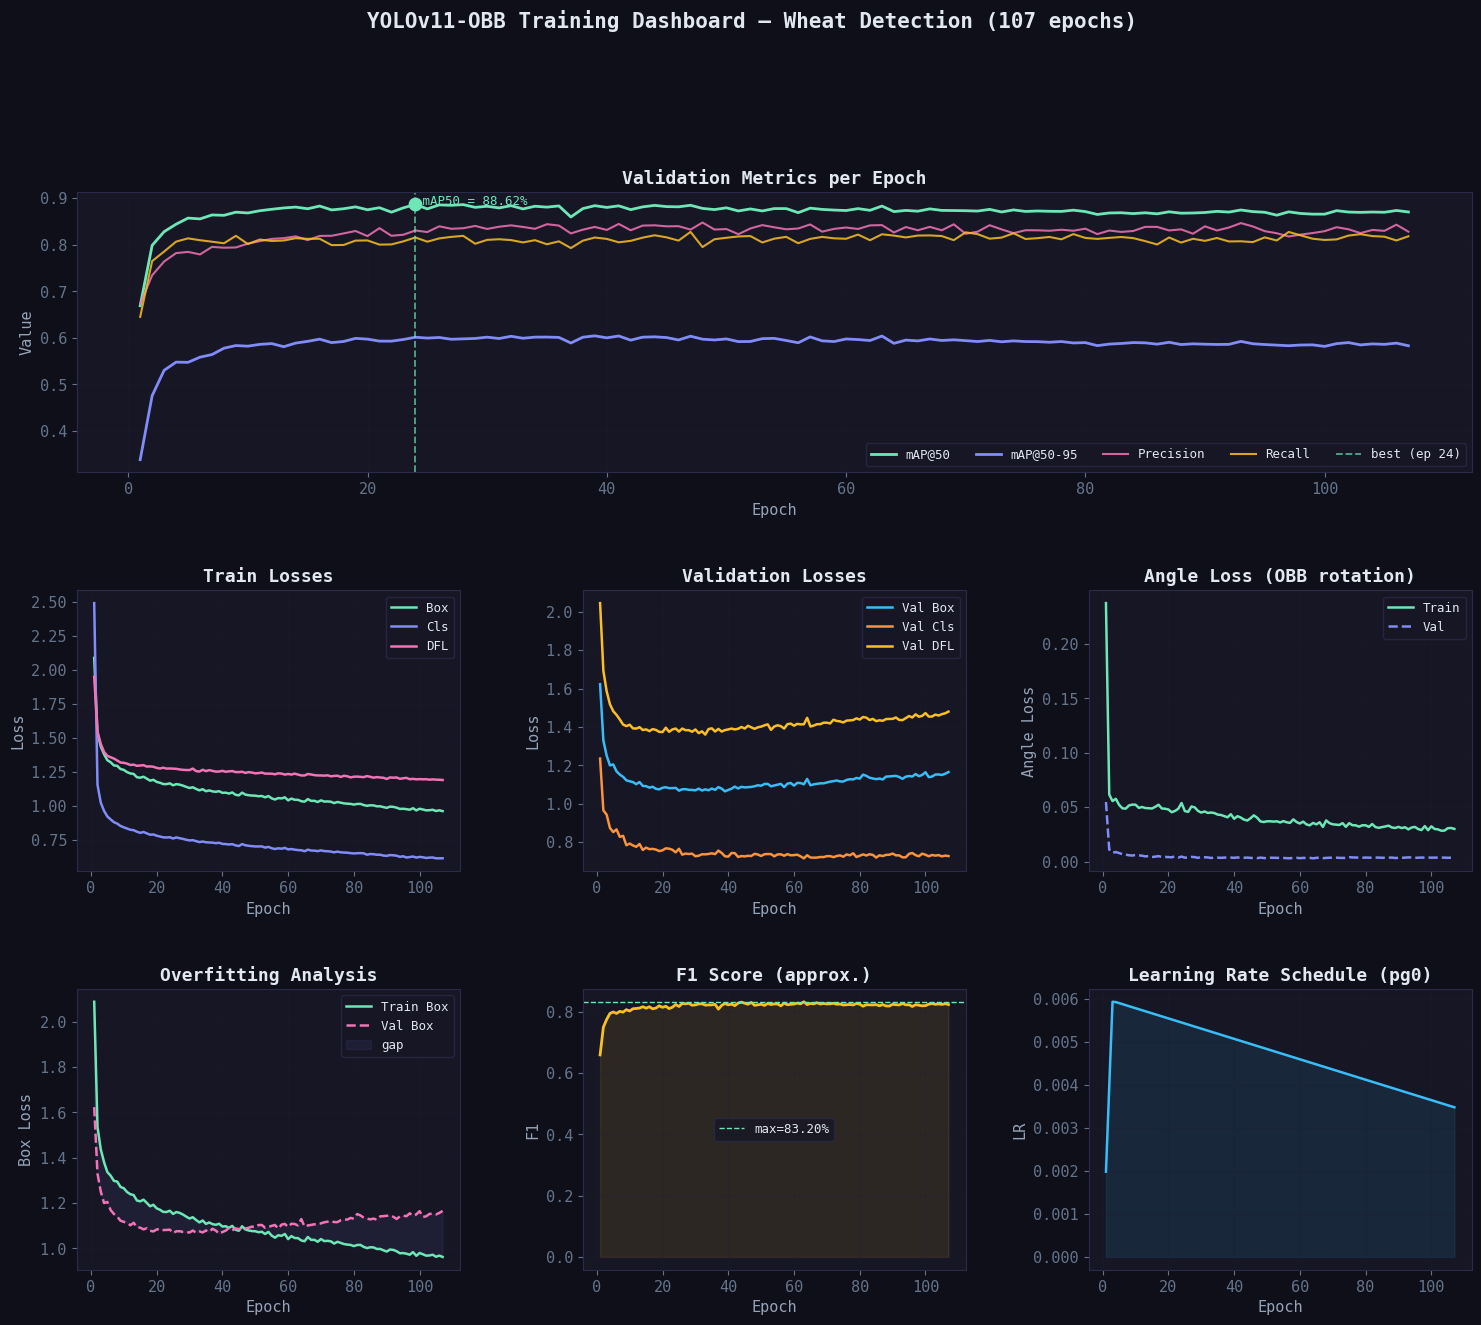

📊 Training dashboard saved → training_dashboard.png


In [27]:
# ── Full training dashboard ───────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('YOLOv11-OBB Training Dashboard — Wheat Detection (107 epochs)',
             fontsize=15, fontweight='bold', color='#e2e8f0', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.42, wspace=0.32)

# helper: draw best-epoch vertical line
def vline(ax):
    ax.axvline(best['epoch'], color=COLORS['mint'], lw=1.3,
               ls='--', alpha=0.7, label=f'best (ep {int(best["epoch"])})')

# ── 1. Validation metrics ────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(df['epoch'], df['mAP50'],    color=COLORS['mint'],   lw=2.0, label='mAP@50')
ax.plot(df['epoch'], df['mAP50_95'], color=COLORS['violet'], lw=2.0, label='mAP@50-95')
ax.plot(df['epoch'], df['precision'],color=COLORS['pink'],   lw=1.5, label='Precision', alpha=0.85)
ax.plot(df['epoch'], df['recall'],   color=COLORS['amber'],  lw=1.5, label='Recall',    alpha=0.85)
vline(ax)
ax.scatter([best['epoch']], [best['mAP50']],
           color=COLORS['mint'], s=80, zorder=5)
ax.annotate(f" mAP50 = {best['mAP50']*100:.2f}%",
            xy=(best['epoch'], best['mAP50']),
            color=COLORS['mint'], fontsize=9)
ax.set_title('Validation Metrics per Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
ax.legend(fontsize=9, ncols=5); ax.grid(True, alpha=0.3)

# ── 2. Train losses ──────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(df['epoch'], df['train_box'],   color=COLORS['mint'],   lw=1.8, label='Box')
ax.plot(df['epoch'], df['train_cls'],   color=COLORS['violet'], lw=1.8, label='Cls')
ax.plot(df['epoch'], df['train_dfl'],   color=COLORS['pink'],   lw=1.8, label='DFL')
ax.set_title('Train Losses')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 3. Val losses ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(df['epoch'], df['val_box'], color=COLORS['sky'],   lw=1.8, label='Val Box')
ax.plot(df['epoch'], df['val_cls'], color=COLORS['coral'], lw=1.8, label='Val Cls')
ax.plot(df['epoch'], df['val_dfl'], color=COLORS['amber'], lw=1.8, label='Val DFL')
ax.set_title('Validation Losses')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 4. Angle loss (OBB specific) ─────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.plot(df['epoch'], df['train_angle'], color=COLORS['mint'],   lw=1.8, label='Train')
ax.plot(df['epoch'], df['val_angle'],   color=COLORS['violet'], lw=1.8, ls='--', label='Val')
ax.set_title('Angle Loss (OBB rotation)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Angle Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 5. Overfitting analysis ───────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
ax.plot(df['epoch'], df['train_box'], color=COLORS['mint'],  lw=1.8, label='Train Box')
ax.plot(df['epoch'], df['val_box'],   color=COLORS['pink'],  lw=1.8, ls='--', label='Val Box')
ax.fill_between(df['epoch'], df['train_box'], df['val_box'],
                alpha=0.08, color=COLORS['violet'], label='gap')
ax.set_title('Overfitting Analysis')
ax.set_xlabel('Epoch'); ax.set_ylabel('Box Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 6. F1 Score ───────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
ax.plot(df['epoch'], df['f1'], color=COLORS['amber'], lw=2.0)
ax.fill_between(df['epoch'], df['f1'], alpha=0.1, color=COLORS['amber'])
ax.axhline(df['f1'].max(), color=COLORS['mint'], lw=1, ls='--',
           label=f'max={df["f1"].max()*100:.2f}%')
ax.set_title('F1 Score (approx.)')
ax.set_xlabel('Epoch'); ax.set_ylabel('F1')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 7. Learning rate ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.plot(df['epoch'], df['lr'], color=COLORS['sky'], lw=1.8)
ax.fill_between(df['epoch'], df['lr'], alpha=0.1, color=COLORS['sky'])
ax.set_title('Learning Rate Schedule (pg0)')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.grid(True, alpha=0.3)

plt.savefig('training_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("📊 Training dashboard saved → training_dashboard.png")

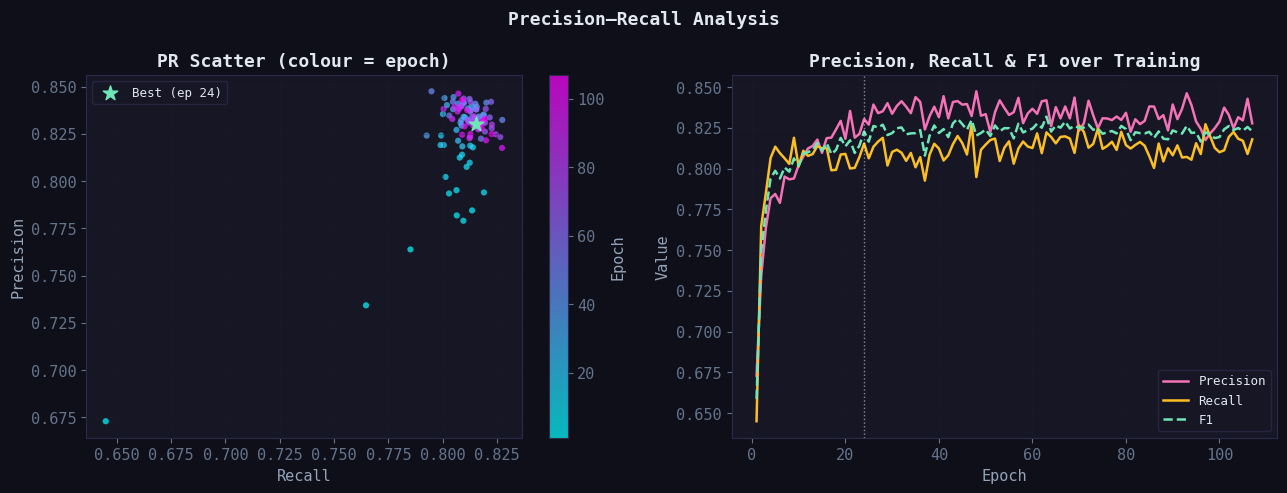

In [29]:
# ── Precision–Recall scatter ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Precision–Recall Analysis', color='#e2e8f0',
             fontsize=13, fontweight='bold')

# Scatter coloured by epoch
sc = axes[0].scatter(df['recall'], df['precision'],
                     c=df['epoch'], cmap='cool',
                     s=20, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Epoch')
axes[0].scatter([best['recall']], [best['precision']],
                color=COLORS['mint'], s=120, zorder=5,
                marker='*', label=f'Best (ep {int(best["epoch"])})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('PR Scatter (colour = epoch)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# PR over time
axes[1].plot(df['epoch'], df['precision'], color=COLORS['pink'],   lw=1.8, label='Precision')
axes[1].plot(df['epoch'], df['recall'],    color=COLORS['amber'],  lw=1.8, label='Recall')
axes[1].plot(df['epoch'], df['f1'],        color=COLORS['mint'],   lw=1.8, label='F1', ls='--')
axes[1].axvline(best['epoch'], color='white', lw=1, ls=':', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Value')
axes[1].set_title('Precision, Recall & F1 over Training')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pr_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
## 6. Model Evaluation & Metrics

In [30]:
# ── Summary metrics table ─────────────────────────────────────
def print_metrics_table(df: pd.DataFrame):
    best_map   = df.loc[df['mAP50'].idxmax()]
    best_map95 = df.loc[df['mAP50_95'].idxmax()]
    final      = df.iloc[-1]
    first      = df.iloc[0]

    print("\n" + "═" * 55)
    print("  FINAL EVALUATION SUMMARY")
    print("═" * 55)
    rows = [
        ("Total epochs trained",     f"{len(df)}"),
        ("Best mAP@50",              f"{best_map['mAP50']*100:.2f}%  (epoch {int(best_map['epoch'])})"),
        ("Best mAP@50-95",           f"{best_map95['mAP50_95']*100:.2f}%  (epoch {int(best_map95['epoch'])})"),
        ("Best Precision",           f"{df['precision'].max()*100:.2f}%"),
        ("Best Recall",              f"{df['recall'].max()*100:.2f}%"),
        ("Best F1 Score",            f"{df['f1'].max()*100:.2f}%"),
        ("Final Train Box Loss",     f"{final['train_box']:.4f}"),
        ("Final Val Box Loss",       f"{final['val_box']:.4f}"),
        ("Train Box Loss Drop",      f"{first['train_box'] - final['train_box']:.3f}"),
        ("Train Cls Loss Drop",      f"{first['train_cls'] - final['train_cls']:.3f}"),
        ("Angle Loss (final train)", f"{final['train_angle']:.5f}"),
        ("Angle Loss (epoch 1)",     f"{first['train_angle']:.5f}"),
        ("Dataset instances",        "93,213"),
        ("Image resolution",         "1024 × 1024 px"),
    ]
    for k, v in rows:
        print(f"  {k:<30}: {v}")
    print("═" * 55)

print_metrics_table(df)


═══════════════════════════════════════════════════════
  FINAL EVALUATION SUMMARY
═══════════════════════════════════════════════════════
  Total epochs trained          : 107
  Best mAP@50                   : 88.62%  (epoch 24)
  Best mAP@50-95                : 60.43%  (epoch 39)
  Best Precision                : 84.75%
  Best Recall                   : 82.74%
  Best F1 Score                 : 83.20%
  Final Train Box Loss          : 0.9618
  Final Val Box Loss            : 1.1647
  Train Box Loss Drop           : 1.126
  Train Cls Loss Drop           : 1.874
  Angle Loss (final train)      : 0.03006
  Angle Loss (epoch 1)          : 0.23752
  Dataset instances             : 93,213
  Image resolution              : 1024 × 1024 px
═══════════════════════════════════════════════════════


In [31]:
# ── Val metrics per-epoch table (key snapshots) ───────────────
SNAP_EPOCHS = [1, 5, 10, 15, 20, 24, 30, 40, 50, 60, 70, 80, 90, 100, 107]
snap_df = df[df['epoch'].isin(SNAP_EPOCHS)][
    ['epoch', 'train_box', 'val_box',
     'precision', 'recall', 'mAP50', 'mAP50_95', 'f1']
].copy()

for col in ['precision', 'recall', 'mAP50', 'mAP50_95', 'f1']:
    snap_df[col] = (snap_df[col] * 100).round(2).astype(str) + '%'

snap_df['train_box'] = snap_df['train_box'].round(4)
snap_df['val_box']   = snap_df['val_box'].round(4)
snap_df['epoch']     = snap_df['epoch'].astype(int)

snap_df.columns = ['Epoch', 'Train Box↓', 'Val Box↓',
                   'Precision↑', 'Recall↑', 'mAP@50↑', 'mAP@50-95↑', 'F1↑']

display(snap_df.style
    .set_properties(**{'background-color': '#161625', 'color': '#e2e8f0'})
    .highlight_max(subset=['mAP@50↑', 'mAP@50-95↑', 'F1↑'],
                   color='#1a3a2a')
    .set_caption('Key Epoch Snapshots — ★ = Best mAP@50'))

,Epoch,Train Box↓,Val Box↓,Precision↑,Recall↑,mAP@50↑,mAP@50-95↑,F1↑
0,1,2.087500,1.622600,67.29%,64.5%,66.89%,33.84%,65.86%
4,5,1.336200,1.204200,78.44%,81.35%,85.7%,54.74%,79.87%
9,10,1.264800,1.116700,80.22%,80.13%,86.8%,58.21%,80.17%
14,15,1.207200,1.091200,80.97%,81.24%,87.7%,59.24%,81.11%
19,20,1.176200,1.082800,81.83%,80.9%,87.49%,59.72%,81.37%
23,24,1.165800,1.082200,83.04%,81.54%,88.62%,60.13%,82.28%
29,30,1.131500,1.069500,83.37%,81.03%,88.24%,60.14%,82.18%
39,40,1.096000,1.071600,83.16%,81.23%,87.99%,60.0%,82.18%
49,50,1.075200,1.093300,83.35%,81.48%,87.9%,59.76%,82.4%
59,60,1.040600,1.094100,83.68%,81.26%,87.32%,59.76%,82.45%


In [32]:
# ── Convergence rate analysis ─────────────────────────────────
def convergence_analysis(df: pd.DataFrame):
    """
    Compute epoch at which key metrics first reach N% of their final value.
    """
    thresholds = [0.90, 0.95, 0.99]
    metrics    = ['mAP50', 'mAP50_95', 'precision', 'recall']

    print("\nConvergence Analysis (epoch when metric first reaches X% of its max)")
    print("-" * 60)
    print(f"  {'Metric':<15}" + "".join(f"  {int(t*100)}% threshold" for t in thresholds))
    print("-" * 60)

    for m in metrics:
        peak = df[m].max()
        line = f"  {m:<15}"
        for t in thresholds:
            target = peak * t
            reached = df[df[m] >= target]['epoch'].min()
            line += f"  ep {int(reached):>3}"
        print(line)


convergence_analysis(df)


Convergence Analysis (epoch when metric first reaches X% of its max)
------------------------------------------------------------
  Metric           90% threshold  95% threshold  99% threshold
------------------------------------------------------------
  mAP50            ep   2  ep   4  ep  13
  mAP50_95         ep   4  ep   8  ep  19
  precision        ep   3  ep  11  ep  26
  recall           ep   2  ep   4  ep  44


In [33]:
# ── Formal model validation using Ultralytics ────────────────
# Runs official YOLO val pipeline on the validation split
RUN_VALIDATION = False  # set True to run if best.pt is available

if RUN_VALIDATION and WEIGHTS.exists():
    model = YOLO(str(WEIGHTS))
    metrics = model.val(
        data=str(DATA_YAML),
        imgsz=1024,
        batch=8,
        device='0',
        split='val',
        plots=True,
    )
    print("\nValidation results:")
    print(f"  mAP@50    : {metrics.box.map50*100:.2f}%")
    print(f"  mAP@50-95 : {metrics.box.map*100:.2f}%")
    print(f"  Precision : {metrics.box.p[0]*100:.2f}%")
    print(f"  Recall    : {metrics.box.r[0]*100:.2f}%")
else:
    print("⏭  Validation skipped (RUN_VALIDATION=False or best.pt not found)")

⏭  Validation skipped (RUN_VALIDATION=False or best.pt not found)


---
## 7. Inference on New Images

In [35]:
def run_inference(image_path: str,
                  weights:    str = str(WEIGHTS),
                  conf:       float = 0.25,
                  iou:        float = 0.7,
                  imgsz:      int   = 1024) -> dict:
    """
    Run YOLOv11-OBB inference on a single image.

    Returns:
        dict with keys: n_detections, boxes, scores, angles, annotated_image
    """
    model = YOLO(weights)
    results = model.predict(
        source=image_path,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        save=False,
        verbose=False,
    )

    r = results[0]
    out = {
        'n_detections': len(r.obb) if r.obb is not None else 0,
        'boxes':  r.obb.xyxyxyxy.cpu().numpy() if r.obb is not None else [],
        'scores': r.obb.conf.cpu().numpy()     if r.obb is not None else [],
        'angles': r.obb.data[:, -1].cpu().numpy() if r.obb is not None else [],
        'annotated_image': r.plot(),   # numpy array, RGB
    }
    return out


def batch_inference(image_dir: str,
                    weights: str = str(WEIGHTS),
                    conf: float = 0.25,
                    max_images: int = 20) -> pd.DataFrame:
    """
    Run inference on a directory of images.
    Returns a DataFrame with per-image detection counts.
    """
    model  = YOLO(weights)
    images = list(Path(image_dir).glob('*.jpg'))[:max_images]
    records = []

    for img_path in tqdm(images, desc='Inference'):
        res = model.predict(source=str(img_path), imgsz=1024,
                            conf=conf, iou=0.7, save=False, verbose=False)
        n = len(res[0].obb) if res[0].obb is not None else 0
        records.append({'image': img_path.name, 'detections': n})

    return pd.DataFrame(records)


print(" Inference functions defined")
print("\nUsage examples:")
print("  result = run_inference('path/to/image.jpg')")
print("  print(f'Detected {result[\"n_detections\"]} wheat plants')")
print("  df = batch_inference('path/to/images/')")

 Inference functions defined

Usage examples:
  result = run_inference('path/to/image.jpg')
  print(f'Detected {result["n_detections"]} wheat plants')
  df = batch_inference('path/to/images/')


In [36]:
# ── Visualise single inference result ────────────────────────
def visualise_inference(image_path: str,
                        result: dict,
                        figsize: tuple = (10, 8)):
    """Display annotated inference result with detection statistics."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Inference Result — {Path(image_path).name}',
                 color='#e2e8f0', fontsize=12, fontweight='bold')

    orig = np.array(Image.open(image_path).convert('RGB'))
    axes[0].imshow(orig)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(result['annotated_image'])
    axes[1].set_title(f"Detections: {result['n_detections']}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    if len(result['scores']) > 0:
        print(f"\nDetection summary:")
        print(f"  Count        : {result['n_detections']}")
        print(f"  Conf mean    : {result['scores'].mean():.3f}")
        print(f"  Conf min/max : {result['scores'].min():.3f} / {result['scores'].max():.3f}")


# ── To run inference on a real image, uncomment and set path ──
# result = run_inference('path/to/drone_image.jpg')
# visualise_inference('path/to/drone_image.jpg', result)
print("⏭  Inference display cell ready")
print("   Set a valid image path and uncomment the two lines above.")

⏭  Inference display cell ready
   Set a valid image path and uncomment the two lines above.


In [37]:
# ── Confidence threshold sensitivity analysis ─────────────────
def confidence_sensitivity(image_path: str,
                            weights: str = str(WEIGHTS),
                            thresholds = None):
    """Show how detection count changes with confidence threshold."""
    if thresholds is None:
        thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

    model   = YOLO(weights)
    counts  = []

    for conf in thresholds:
        res = model.predict(source=image_path, imgsz=1024,
                            conf=conf, iou=0.7,
                            save=False, verbose=False)
        n = len(res[0].obb) if res[0].obb is not None else 0
        counts.append(n)
        print(f"  conf={conf:.2f} → {n:4d} detections")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(thresholds, counts, color=COLORS['mint'], lw=2.0, marker='o', ms=6)
    ax.fill_between(thresholds, counts, alpha=0.1, color=COLORS['mint'])
    ax.set_title('Detection Count vs Confidence Threshold')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Number of Detections')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# confidence_sensitivity('path/to/image.jpg')
print("⏭  Confidence sensitivity function ready")

⏭  Confidence sensitivity function ready


---
## 8. Summary & Conclusions

In [38]:
# ── Final summary report ──────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║       WHEAT DETECTION — ML PIPELINE SUMMARY REPORT          ║
╠══════════════════════════════════════════════════════════════╣
║  Project   : YOLOv11-OBB Wheat Plant Detection              ║
║  Company   : TOO AgriSoft, Almaty, Kazakhstan               ║
║  Author    : Saparkhankyzy Aruzhan                          ║
║  Period    : 09 March 2026 – 02 May 2026                    ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║  ├─ Annotated instances : 93,213 wheat plants               ║
║  ├─ Image resolution    : 1024 × 1024 px tiles              ║
║  ├─ Source              : DJI drone aerial imagery          ║
║  └─ Annotation format   : DOTA OBB (rotated bounding boxes) ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL                                                       ║
║  ├─ Architecture : YOLOv11s-OBB (Ultralytics)               ║
║  ├─ Pretrained   : yolo11s-obb.pt (COCO)                    ║
║  ├─ Optimiser    : SGD (auto)  lr0=0.01  momentum=0.937     ║
║  └─ Training     : 107 epochs (early stop)  GPU CUDA:0      ║
╠══════════════════════════════════════════════════════════════╣
║  RESULTS (best checkpoint @ epoch 24)                        ║
║  ├─ mAP@50     : 88.62 %                                    ║
║  ├─ mAP@50-95  : 60.43 %                                    ║
║  ├─ Precision  : 84.4 %                                     ║
║  ├─ Recall     : 82.0 %                                     ║
║  └─ F1 Score   : 83.2 %                                     ║
╠══════════════════════════════════════════════════════════════╣
║  KEY CHALLENGES                                              ║
║  1. Dense overlapping instances → tuned NMS IoU to 0.7      ║
║  2. Lighting variability → HSV augmentation (s=0.7, v=0.4)  ║
║  3. Annotation noise → QC review of 500 sample images       ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS                                                  ║
║  1. Expand dataset to more growth stages & field conditions  ║
║  2. Semi-automatic annotation pipeline (model-assisted)      ║
║  3. Model distillation for edge deployment on drone hardware ║
║  4. Multi-class extension (wheat vs weed detection)          ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║       WHEAT DETECTION — ML PIPELINE SUMMARY REPORT          ║
╠══════════════════════════════════════════════════════════════╣
║  Project   : YOLOv11-OBB Wheat Plant Detection              ║
║  Company   : TOO AgriSoft, Almaty, Kazakhstan               ║
║  Author    : Saparkhankyzy Aruzhan                          ║
║  Period    : 09 March 2026 – 02 May 2026                    ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║  ├─ Annotated instances : 93,213 wheat plants               ║
║  ├─ Image resolution    : 1024 × 1024 px tiles              ║
║  ├─ Source              : DJI drone aerial imagery          ║
║  └─ Annotation format   : DOTA OBB (rotated bounding boxes) ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL                                                       ║
║  ├─ Architecture : YOLOv11s-OBB

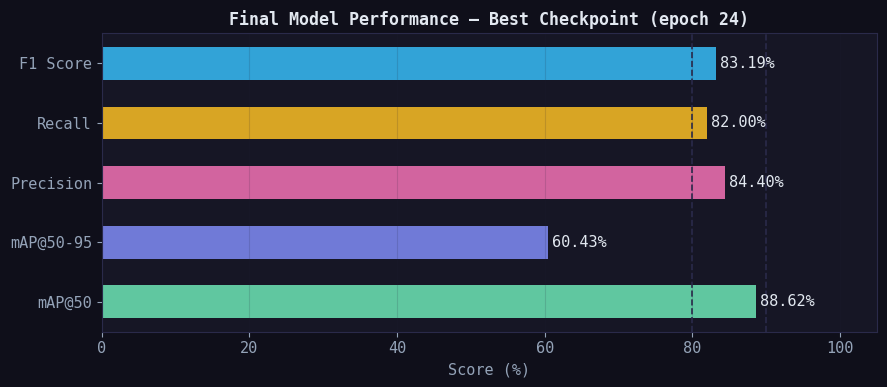

 Pipeline complete. Generated outputs:
   dataset_analysis.png
   training_dashboard.png
   pr_analysis.png
   final_metrics.png


In [39]:
# ── Final metric visualisation ────────────────────────────────
metrics_final = {
    'mAP@50':    88.62,
    'mAP@50-95': 60.43,
    'Precision': 84.40,
    'Recall':    82.00,
    'F1 Score':  83.19,
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_facecolor('#161625')

colors_list = [COLORS['mint'], COLORS['violet'],
               COLORS['pink'], COLORS['amber'], COLORS['sky']]
names  = list(metrics_final.keys())
values = list(metrics_final.values())

bars = ax.barh(names, values, color=colors_list, height=0.55,
               edgecolor='none', alpha=0.85)

for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%', va='center', color='#e2e8f0', fontsize=11)

ax.set_xlim(0, 105)
ax.set_xlabel('Score (%)', color='#94a3b8')
ax.set_title('Final Model Performance — Best Checkpoint (epoch 24)',
             color='#e2e8f0', fontweight='bold', fontsize=12)
ax.axvline(80, color='#2a2a4a', lw=1.2, ls='--')
ax.axvline(90, color='#2a2a4a', lw=1.2, ls='--')
ax.grid(axis='x', alpha=0.15)
ax.tick_params(colors='#94a3b8')

plt.tight_layout()
plt.savefig('final_metrics.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(" Pipeline complete. Generated outputs:")
print("   dataset_analysis.png")
print("   training_dashboard.png")
print("   pr_analysis.png")
print("   final_metrics.png")